# Understanding the local electricity market

## 📖 Background
You work for an energy company in Australia. Your company builds solar panel arrays and then sells the energy they produce to industrial customers. The company wants to expand to the city of Melbourne in the state of Victoria. 

Prices and demand for electricity change every day. Customers pay for the energy received using a formula based on the local energy market's daily price.

Your company's pricing committee wants your team to estimate energy prices for the next 12-18 months to use those prices as the basis for contract negotiations.

In addition, the VP of strategy is researching investing in storage capacity (i.e., batteries) as a new source of revenue. The plan is to store some of the energy produced by the solar panels when pricing conditions are unfavorable and sell it by the next day on the open market if the prices are higher.

## 💾 The data
You have access to over five years of energy price and demand data ([source](https://www.kaggle.com/aramacus/electricity-demand-in-victoria-australia)):

- "date" - from January 1, 2015, to October 6, 2020.
- "demand" - daily electricity demand in MWh.
- "price" - recommended retail price in AUD/MWh.
- "demand_pos_price" - total daily demand at a positive price in MWh.
- "price_positive" - average positive price, weighted by the corresponding intraday demand in AUD/MWh.
- "demand_neg_price" - total daily demand at a negative price in MWh.
- "price_negative" - average negative price, weighted by the corresponding intraday demand in AUD/MWh.
- "frac_neg_price" - the fraction of the day when the demand traded at a negative price.
- "min_temperature" - minimum temperature during the day in Celsius.
- "max_temperature" - maximum temperature during the day in Celsius.
- "solar_exposure" - total daily sunlight energy in MJ/m^2.
- "rainfall" - daily rainfall in mm.
- "school_day" - "Y" if that day was a school day, "N" otherwise.
- "holiday" - "Y" if the day was a state or national holiday, "N" otherwise.

Note: The price was negative during some intraday intervals, so energy producers were paying buyers rather than vice-versa.

In [1]:
# %%capture
# !pip install --upgrade scipy 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# from pandas import datetime
from datetime import timedelta
import seaborn as sns
# import missingno as msno
# import plotly.express as px
import scipy 
import warnings
warnings.filterwarnings("ignore")

sns.set_palette('Spectral')

In [4]:
df = pd.read_csv('./data/energy_demand.csv', parse_dates=['date'])
df = round(df, 2)
df.head()

,date,demand,price,demand_pos_price,price_positive,demand_neg_price,price_negative,frac_neg_price,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday
0,2015-01-01,99635.03,25.63,97319.24,26.42,2315.79,-7.24,0.02,13.3,26.9,23.6,0.0,N,Y
1,2015-01-02,129606.01,33.14,121082.01,38.84,8523.99,-47.81,0.06,15.4,38.8,26.8,0.0,N,N
2,2015-01-03,142300.54,34.56,142300.54,34.56,0.00,0.00,0.00,20.0,38.2,26.5,0.0,N,N
3,2015-01-04,104330.72,25.01,104330.72,25.01,0.00,0.00,0.00,16.3,21.4,25.2,4.2,N,N
4,2015-01-05,118132.20,26.72,118132.20,26.72,0.00,0.00,0.00,15.0,22.0,30.7,0.0,N,N


# 1. Data Cleaning.

In [5]:
df.shape

(2106, 14)

In [6]:
df.isna().sum() # Checking missing values.

date                0
demand              0
price               0
demand_pos_price    0
price_positive      0
demand_neg_price    0
price_negative      0
frac_neg_price      0
min_temperature     0
max_temperature     0
solar_exposure      1
rainfall            3
school_day          0
holiday             0
dtype: int64

In [7]:
df.dropna(inplace=True) #Dropping missing values.

In [8]:
df.duplicated().sum() # Checking duplicated observations.

0

In [9]:
df['month'] = df['date'].dt.month_name()
df['month_num'] = df.date.dt.month
df['year'] = df.date.dt.year
df['day'] = df['date'].dt.day
df['week_day'] = df['date'].dt.day_name()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2102 entries, 0 to 2105
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              2102 non-null   datetime64[ns]
 1   demand            2102 non-null   float64       
 2   price             2102 non-null   float64       
 3   demand_pos_price  2102 non-null   float64       
 4   price_positive    2102 non-null   float64       
 5   demand_neg_price  2102 non-null   float64       
 6   price_negative    2102 non-null   float64       
 7   frac_neg_price    2102 non-null   float64       
 8   min_temperature   2102 non-null   float64       
 9   max_temperature   2102 non-null   float64       
 10  solar_exposure    2102 non-null   float64       
 11  rainfall          2102 non-null   float64       
 12  school_day        2102 non-null   object        
 13  holiday           2102 non-null   object        
 14  month             2102 non-nu

# 2. Data Exploration.

In [12]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,2102,2017-11-18 14:40:18.268315904,2015-01-01 00:00:00,2016-06-10 06:00:00,2017-11-17 12:00:00,2019-04-29 18:00:00,2020-10-06 00:00:00,NaN
demand,2102.0,120036.408026,85094.37,110011.5925,119605.24,130436.0025,170653.84,13747.23546
price,2102.0,76.084986,-6.08,38.71,66.52,95.075,4549.65,130.367073
demand_pos_price,2102.0,119251.74628,41988.24,109246.2475,119169.065,130119.4775,170653.84,14819.902259
price_positive,2102.0,76.560167,13.57,39.12,66.85,95.1325,4549.65,130.234309
demand_neg_price,2102.0,784.661765,0.0,0.0,0.0,0.0,57597.6,3582.162756
price_negative,2102.0,-2.691166,-342.22,0.0,0.0,0.0,0.0,19.503629
frac_neg_price,2102.0,0.00843,0.0,0.0,0.0,0.0,0.62,0.039754
min_temperature,2102.0,11.579924,0.6,8.5,11.3,14.6,28.0,4.311288
max_temperature,2102.0,20.415557,9.0,15.525,19.1,23.9,43.5,6.28995


<p> The price columns has extremely high values (over $4000); these are extreme values that could bias our analysis and model predictor. We will filter our price values on the 95th quantile to check if exists any pattern.

In [13]:
quantile =  df['price'].quantile(0.95)
print('The 95th quantile value for price is:', quantile) # 95th quantile value for filtering.

The 95th quantile value for price is: 132.547


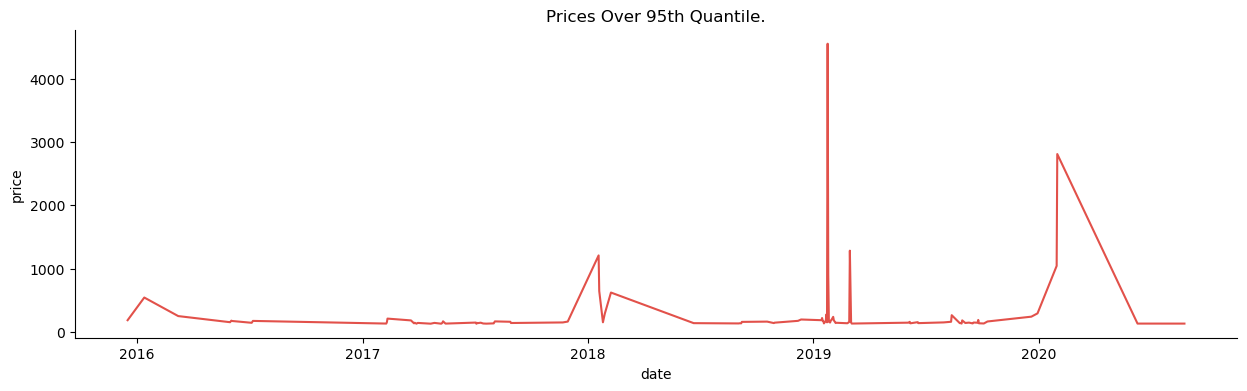

In [14]:
plt.figure(figsize=(15, 4))
extreme_prices = df[df['price'] >= quantile]
sns.lineplot(x='date', y='price', data=extreme_prices)
plt.title('Prices Over 95th Quantile.')
sns.despine()

From the graph is clear that there have been a really high spikes on retail prices in the last three years (2018-2019-2020), being 2019 the year with the highest of over $4000. Now let's zoom on each specific year to verify is this a cyclical pattern or just randomness.

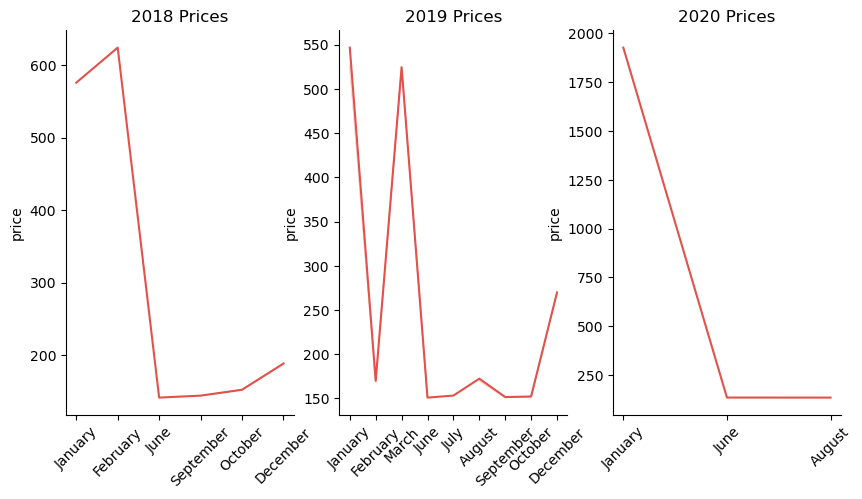

In [15]:

plt.figure(figsize=(10, 5))
plt.subplot(131)
a = extreme_prices[extreme_prices['year']==2018]
sns.lineplot(x='month', y='price', data=a, ci=False)
plt.title('2018 Prices')
plt.xticks(rotation=45)
plt.xlabel('')
sns.despine()

plt.subplot(132)
b = extreme_prices[extreme_prices['year']==2019]
sns.lineplot(x='month', y='price', data=b, ci=False)
plt.title('2019 Prices')
plt.xticks(rotation=45)
plt.xlabel('')
sns.despine()

plt.subplot(133)
c = extreme_prices[extreme_prices['year']==2020]
sns.lineplot(x='month', y='price', data=c, ci=False)
plt.title('2020 Prices')
plt.xticks(rotation=45)
plt.xlabel('')
sns.despine()


In every year, starting on December, electricity prices start climbing up until February-March and then begins to descend until June and stays in low levels. Nevertheless, we will filter our dataset to the 95th percentile.

In [16]:
df = df[df['price'] <= quantile] # Filtering dataset.

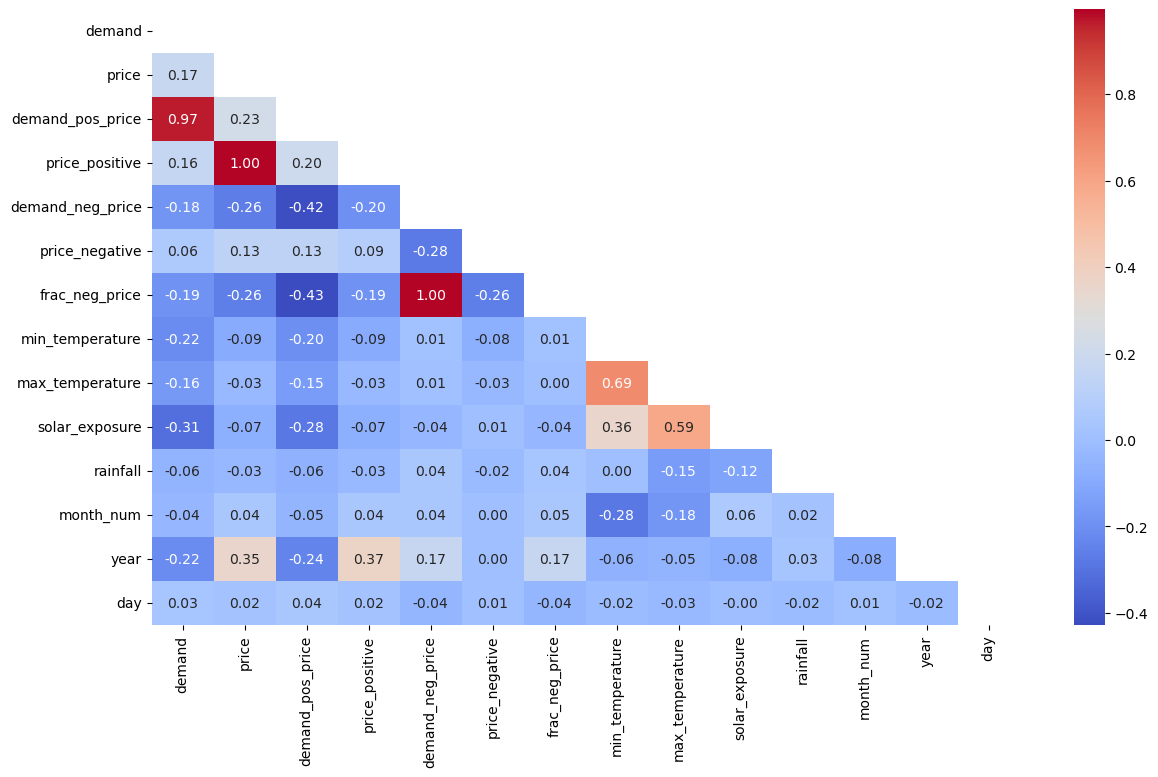

In [19]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix))

plt.figure(figsize=(14, 8))
sns.heatmap(corr_matrix, annot=True, mask=mask, cmap="coolwarm", fmt=".2f")
plt.show()

### 2.1  How do energy prices change throughout the year?

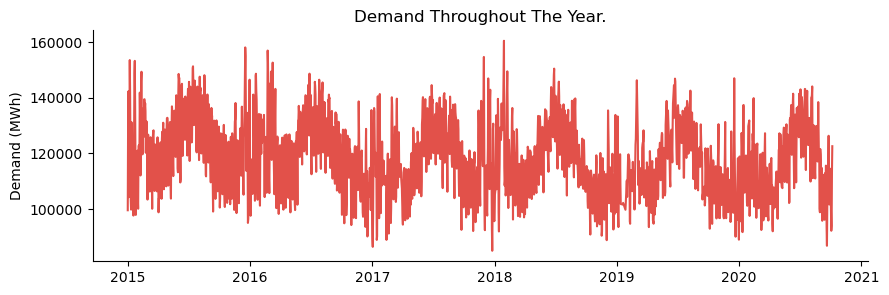

In [23]:
plt.figure(figsize=(10, 3))
sns.lineplot(x='date', y='demand', data=df)
plt.xlabel('')
plt.ylabel('Demand (MWh)')
sns.despine()
plt.title('Demand Throughout The Year.');

### 2.2 How to energy change by month?

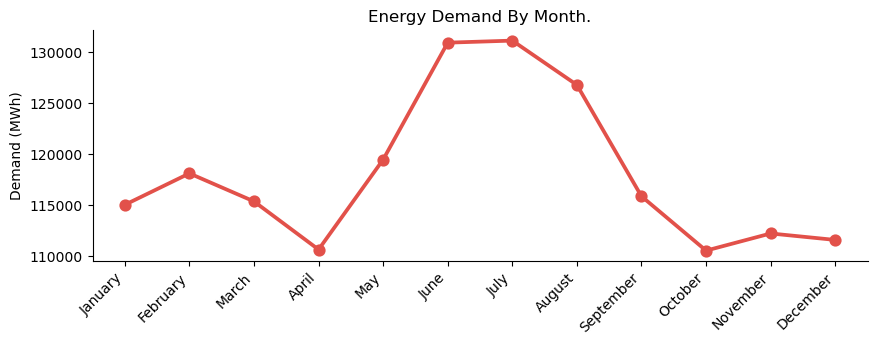

In [24]:
plt.figure(figsize=(10, 3))
ax = sns.pointplot(x='month', y='demand_pos_price', data=df, ci=False)

plt.xlabel('')
plt.xticks(rotation=45, ha="right")
plt.ylabel('Demand (MWh)')
sns.despine()
plt.title('Energy Demand By Month.');

<p> In Australia, the seasons are defined by grouping the calendar months in the following way:

<li>Spring - the three transition months September, October and November.
<li>Summer - the three hottest months December, January and February.
<li>Autumn - the transition months March, April and May.
<li>Winter - the three coldest months June, July and August.<p>

<p> From the graph we see that in the summer season there is a slightly demand for energy but from the end of Autumn (April-May) we can observe a gradual increase in energy demand that stay flat peaked for all winter's season and then drops hastily when spring arrives.

### 2.3 How do energy demande changes by day of month?

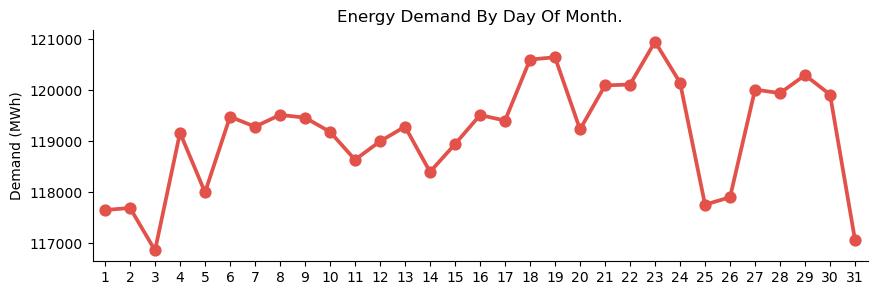

In [25]:
plt.figure(figsize=(10, 3))
sns.pointplot(x='day', y='demand', data=df, ci=False)
plt.xlabel('')
plt.ylabel('Demand (MWh)')
sns.despine()
plt.title('Energy Demand By Day Of Month.');

### 2.4 How do energy demand changes by day of week?

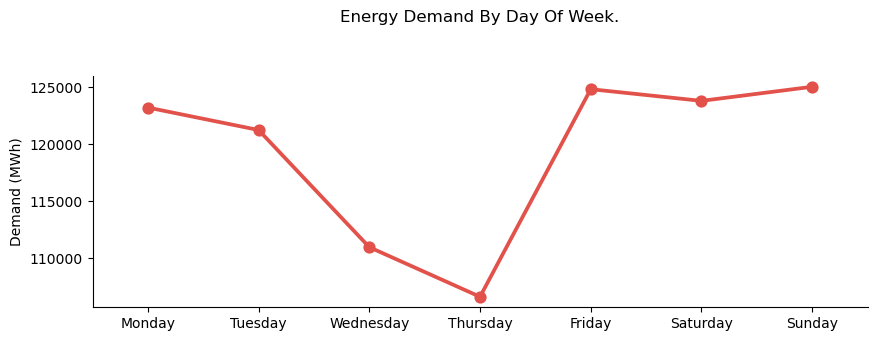

In [26]:
a = df.groupby('week_day')[['demand', 'price']].mean().reset_index()

plt.figure(figsize=(10, 3))
ax = sns.pointplot(x='week_day', y='demand', data=a)
for p in ax.patches:
	plt.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   size=12,
                   xytext = (0, 7), 
                   textcoords = 'offset points')
plt.xticks(range(7), ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.xlabel('')
plt.ylabel('Demand (MWh)')
sns.despine()
plt.title('Energy Demand By Day Of Week.', y=1.2);

### 2.5 How does energy demand relates to price?

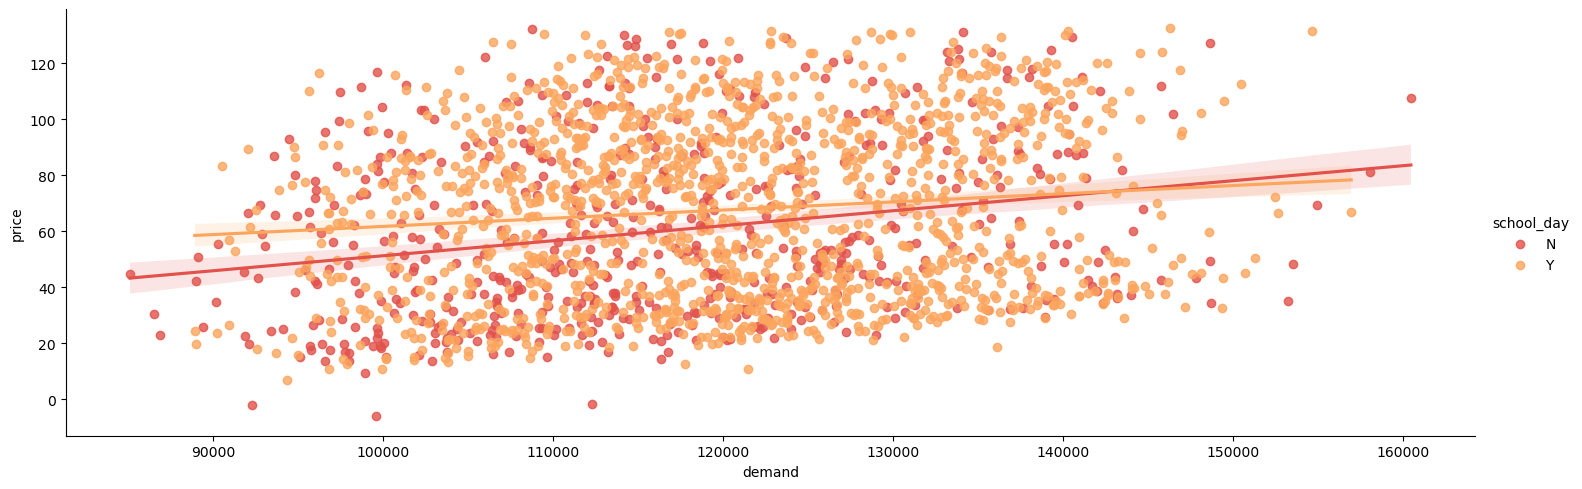

In [27]:
sns.lmplot(x='demand', y='price', data=df, hue='school_day', aspect=3)
sns.despine()

<p> Visually, we can observe a positive relationship between demand and price. That is: as demand rises, price also goes up with it. But how strong is that relationship? We will use the Spearman rank-order correlation to measure this effect.<p>
<p> Another thing, the slope of the school_day = 'N' is a bit steeper than school_day = 'Y'. This indicate that when children and student are at home, energy demand rises jointly with prices.<p>
<p> In addtion, we'll use its p-value (alternative=greater) to see if we can reject the Null Hypotesis that there is no such thing as a postive relationship (>0) between these variables.

In [22]:
# corr, p_val = scipy.stats.spearmanr(df['price'], df['demand'], alternative='greater')
# if p_val < 0.05:
#     print('There exists a positive relationship!')
#     print('Correlation:', corr.round(2))

<p> According to the test, there exists indeed a positive relationship between price and demand, although we could argue that the value is weak nontheless.

### 2.6 How does prices fluctuates over time?

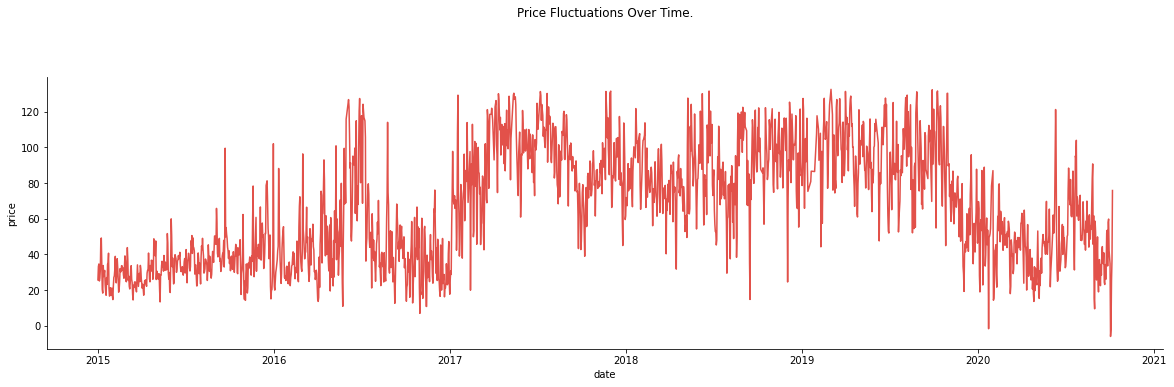

In [23]:
plt.figure(figsize=(20, 5))
sns.lineplot(x='date', y='price', data=df)
plt.title('Price Fluctuations Over Time.', y=1.2)
sns.despine()

<p> Unlike energy demand, who has followed a cyclical pattern over time, energy prices had seen a small increase starting in 2017 until 2020. After that, it has decresead to the levels before the rise.

### 2.7  When do retail prices go below zero?

In [24]:
count_neg_prices = len(df[df['demand_neg_price']>0])
frac_neg_prices = round((count_neg_prices / len(df)) * 100, 2)

print('Retail prices went below zero {0} times. That represents {1}% over a period of 68 months.'.format(count_neg_prices, frac_neg_prices))

Retail prices went below zero 190 times. That represents 9.52% over a period of 68 months.


In [25]:
pos_price_by_month = df[df['demand_pos_price'] > 0].groupby(['year','month_num'])[['price']].count().reset_index()
neg_price_by_month = df[df['demand_neg_price'] > 0].groupby(['year','month_num'])[['price']].count().reset_index()

In [26]:
neg_price_by_month['ratio_neg_month'] = neg_price_by_month['price'].div(pos_price_by_month['price'], axis=0)

In [27]:
neg_price_by_month['price'] = -1 * neg_price_by_month['price'] # Convert to negative so they appear in the lower part of graph.

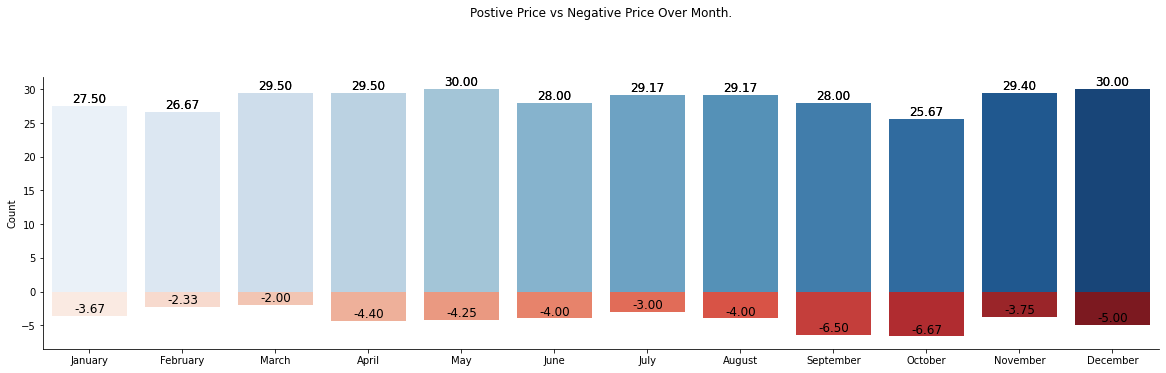

In [28]:
plt.figure(figsize=(20, 5))
ax = sns.barplot(x='month_num', y='price', data=pos_price_by_month, palette = 'Blues', ci=False)
for p in ax.patches:
	plt.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   size=12,
                   xytext = (0, 7), 
                   textcoords = 'offset points')
ax2 = sns.barplot(x='month_num', y='price', data=neg_price_by_month, palette = 'Reds', ci=False)
for p in ax2.patches:
	plt.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   size=12,
                   xytext = (0, 7), 
                   textcoords = 'offset points')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(range(12), labels=df['month'].unique())

plt.title('Postive Price vs Negative Price Over Month.', y=1.2)
sns.despine()

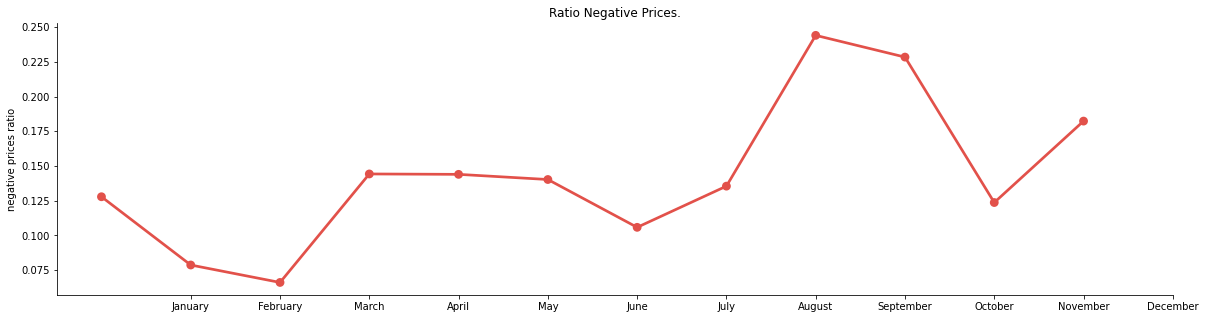

In [29]:
plt.figure(figsize=(20, 5))
sns.pointplot(x='month_num', y='ratio_neg_month', data=neg_price_by_month, ci=False)
plt.ylabel('negative prices ratio')
plt.xlabel('')
plt.xticks(range(1, 13), labels=df['month'].unique())
plt.title('Ratio Negative Prices.')
sns.despine()

<p> From months July - October there is a increase in negative prices. From <a href="https://app.datacamp.com/workspace/w/af6be56a-687f-4ea3-8a0d-2a1dadb79655/edit#iiii-how-to-energy-change-by-month"> II.II</a>  we see that from those exact months, a decrease in energy demand takes place.

### 2.8 Are Colder Weather Conditions Really Increase Energy Demand?

<p> <a href="https://app.datacamp.com/workspace/w/af6be56a-687f-4ea3-8a0d-2a1dadb79655/edit#iiii-how-to-energy-change-by-month">From II.II</a> we saw that the coldest months are the months that really drives up the energy demand, so we could infer that there exists a relationship between temperature and demand (As temperature decreases demand goes up).

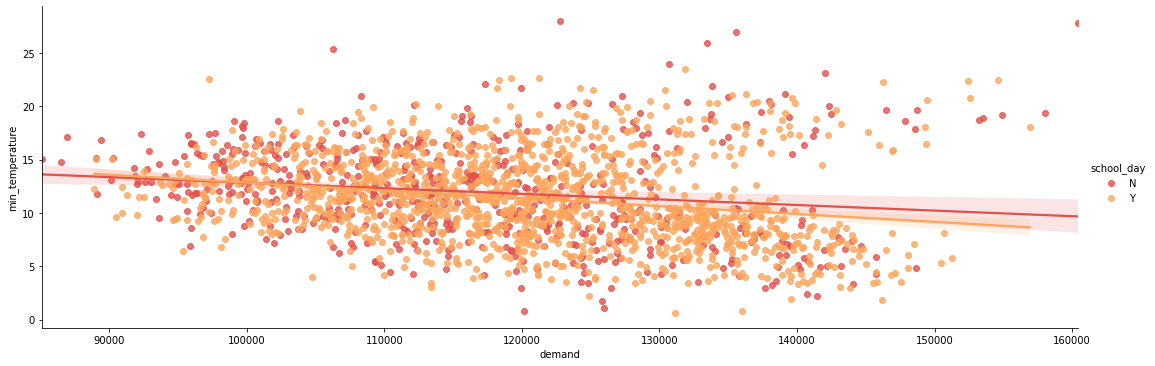

In [30]:
sns.lmplot(x='demand', y='min_temperature', data=df, hue='school_day', aspect=3)
sns.despine()

### 2.9 Are Holiday Days More Energy-Demanding?

In [31]:
holiday = df[df['holiday'] == 'Y']['demand'] # Energy Demand For Holidays.
no_holiday = df[df['holiday'] == 'N']['demand'] # Energy Demand For Regular Days.

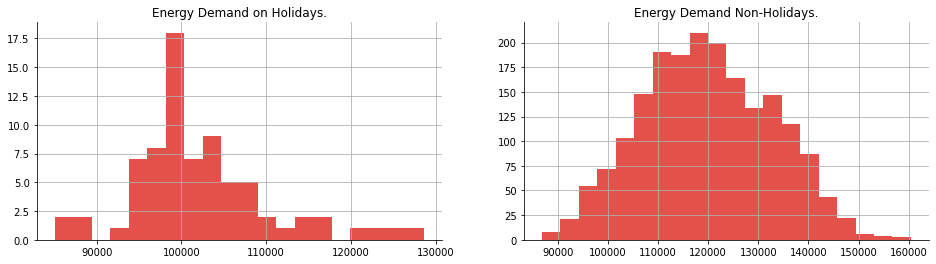

In [32]:
plt.figure(figsize=(16, 4))
plt.subplot(121)
holiday.hist(bins=20)
plt.title('Energy Demand on Holidays.')
sns.despine()
plt.subplot(122)
no_holiday.hist(bins=20)
plt.title('Energy Demand Non-Holidays.')
sns.despine()

<p> The two-sample t-test (also known as the independent samples t-test) is a method used to test whether the unknown population means of two groups are equal or not. But there are three important asumptions:<p>
<li> Data values are independent.
<li> Values are randomly sampled from two normal populations.
<li> The two independent groups have equal variances.

In [33]:
round(no_holiday.var()/ holiday.var(), 3) # Check For Homoscedasticity. If (Var1/ Var2) < 4, we conclude that groups have equal variances.

2.584

In [34]:
_, p_val = scipy.stats.kstest(holiday, cdf='norm') # Check For Normality.
print(p_val)

0.0


***Null Hypotesis: Both groups have identical energy demand average.***<br><br>
***Alternative Hypotesis: Holiday days have less energy demand by average than Non-holidays.***

In [35]:
# _, p_val = scipy.stats.ttest_ind(holiday, no_holiday, alternative='less')
# print(p_val)

<p> If we choose a significance level alpha to be 0.05, we can reject our Null Hypotesis that holiday periods and regular days don't have the same energy demand by average; more precisely: we can conclude that on holidays, the energy demand is statistically lower.

### How does solar exposure varies between seasons? 

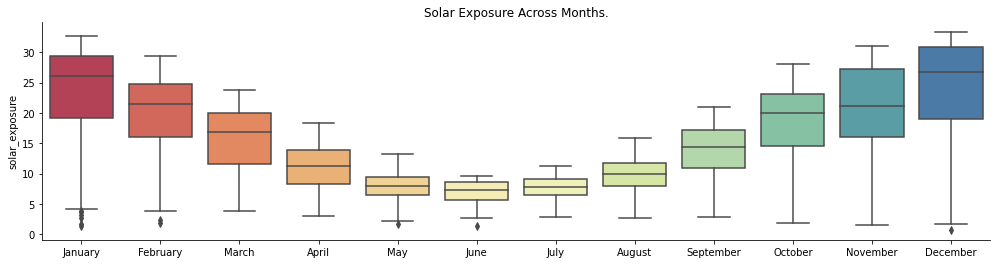

In [36]:
plt.figure(figsize=(17, 4))
sns.boxplot(x='month_num', y='solar_exposure', data=df, palette = 'Spectral')
plt.xticks(range(0, 12), labels=df.month.unique())
plt.xlabel('')
plt.title('Solar Exposure Across Months.')
sns.despine()

<p> As we could expect, there exists a seasonal pattern of solar exposure : Summer and Autumn seasons see the highest amount of solar exposure, whereas Fall and Winter have the lowest values.<p>

# 3.0 Price Forecasting.

In [37]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import arma_order_select_ic
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product 

In [38]:
data = df.copy().set_index('date')
data = data.asfreq('M', method='ffill').dropna()

In [39]:
print(f'We have {data.shape[0]} montly price observations.')

We have 69 montly price observations.


In [40]:
rolling_mean = data.price.rolling(window=6).mean()
rolling_std = data.price.rolling(window=1).std()

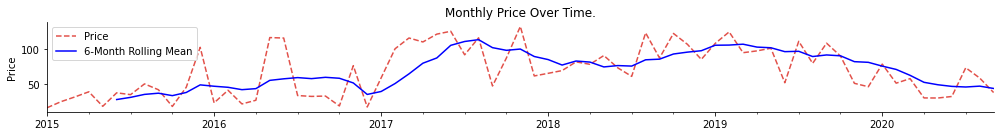

In [41]:
fig, ax = plt.subplots(figsize=(14, 2))
data.price.plot(linestyle='--', ax=ax)
rolling_mean.plot(ax=ax, color='b')
plt.xlabel('')
plt.ylabel('Price')
plt.title('Monthly Price Over Time.')
plt.legend(['Price', '6-Month Rolling Mean'], loc='upper left')
plt.tight_layout()
sns.despine()

<p> A stationary time series is one whose statistical properties do not change over time. In other 
words, it has a constant mean, variance, and autocorrelation, and these properties are 
independent of time. We can clearly see that price values are not stationary because fluctuations are time-dependent. 

### 3.1 Augmented Dickey-Fuller Test(ADF).

The null hypothesis of the Augmented Dickey-Fuller (ADF) is that there is a unit root, with the alternative that there is no unit root.<br><br>
**Null hypotesis: Time series is non-stationary.**<br>
**Alternative Hypotesis: Time series is stationary.**

In [42]:
X = data.price.values
result = adfuller(X)
adfuller(X)
if result[1] <0.05:
    print('Time Series is stationary.')
else:
    print('Time-serie is non-stationary.')

Time-serie is non-stationary.


<p> To achieve stationarity, the simplest transformation one can apply is differencing. This transformation helps stabilize the mean, which in turn removes or reduces the trend and seasonality effects.<p> 
<p> We'll be taking the difference once. This is called a first-order differencing.

In [43]:
data['price_diff'] = data.price.diff() # Differencing price column for stationarity.
data.dropna(inplace=True)

In [44]:
X = data['price_diff']
result = adfuller(X)
adfuller(X)
if result[1] <0.05:
    print('Time Series is stationary.')
else:
    print('Time-serie is non-stationary.')

Time Series is stationary.


### 3.2 Seasonal Decomposition.

<p> Time series decomposition is a statistical task that separates the time series into its three main components: a trend 
component, a seasonal component, and the residuals. 
The trend component represents the long-term change in the time series. This component is responsible for time 
series that increase or decrease over time. The seasonal component is of course the periodic pattern in the time 
series. It represents repeated fluctuations that occur over a fixed period of time. Finally, the residuals, or the noise, 
express any irregularity that cannot be explained by the trend or the seasonal component. 

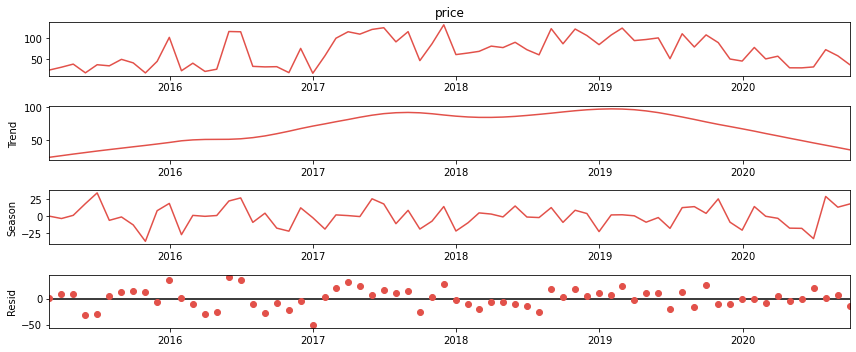

In [45]:
from statsmodels.tsa.seasonal import STL
stl = STL(data.price, period=12)
res = stl.fit()
plt.rcParams["figure.figsize"] = (12,5)
fig = res.plot()

<p> We don't visually observe any sign of seasonality on this specific dataset, so there is no need to utilize a more complex model that takes into account seasonality like SARIMA.

### 3.3 Autocorrelation Function (ACF) & Partial Autocorrelation Function (PACF).

<p> The Autocorrelation function (ACF) measures the linear relationship between lagged values of a time series. Thus, the autocorrelation function reveals how the correlation between any two values changes as the lag increases. 

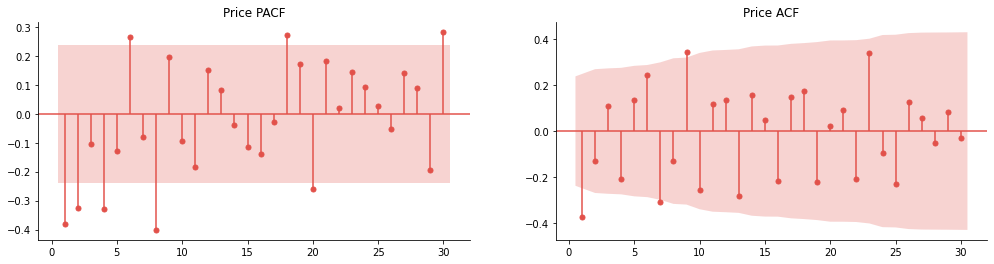

In [46]:
fig, (ax, ax2) = plt.subplots(figsize=(17, 4), nrows=1, ncols=2)
plot_pacf(x=data.price_diff, ax=ax, zero=False, title='Price PACF', lags=30)
plot_acf(data.price_diff, ax=ax2, zero=False, title='Price ACF', lags=30)
sns.despine()

<p> From the ACF plot, we can conclude that after differenciating price, thus making it stationary, coefficients of recent lags showed significantly different from zero. This means that price is not a "Random Walk", thus could be potentially modeled.

<p>Looking at the ACF plot, we can reason that because the coefficients do not become abruptly non-significant after some lag q, the process cannot be modeled using a Moving Average Model.<p>
<p>Looking at the PACF plot, we can reason that because the coefficients do not become abruptly non-significant after some lag p, the process cannot be modeled using a Autoregression Model.<p>
<p> The third option is a combination of both AR & MA. Both the ACF and PACF plots show a decaying pattern or sinusoidal pattern, then it is most likely a stationary ARMA(p,q) process.

### 3.4 Baseline model.

<p> A baseline model is a trivial solution to our problem. It often uses heuristics, or simple 
statistics, to generate predictions. We could suppose that using the last known value of the training set as a 
baseline model will give usa a better baseline model's forecast, which would translate in a MAPE close to 
0%.

In [47]:
train = data.price.iloc[:-12]
test = data.price.iloc[-12:] # Predict the last twelve months.

In [48]:
naive = []
for i in range(len(train), len(data)):
    last_value = round(data.price[:i].iloc[-1],2)
    naive.append(last_value)

In [49]:
naive_df = pd.DataFrame(naive, index=test.index) # Transforming to DataFrame.

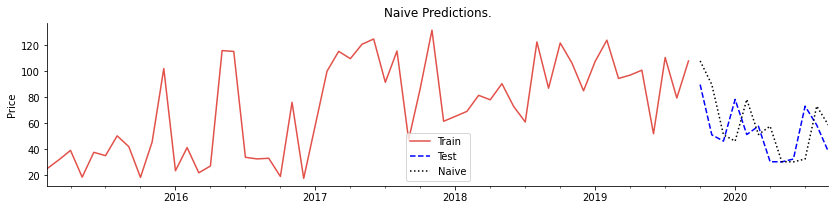

In [50]:
fig,ax = plt.subplots(figsize=(14,3))
train.plot(ax=ax)
test.plot(ax=ax, linestyle='--', color='b')
naive_df.plot(ax=ax, linestyle=':', color='k')
plt.legend(['Train','Test', 'Naive'], loc='lower center')
plt.xlabel('')
plt.ylabel('Price')
plt.title('Naive Predictions.')
sns.despine()

In [51]:
def mape(y_true, y_pred): 
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return round(mape,1)

In [52]:
mape_ = mape(test, naive_df[0])
print(f'Our naive model deviates {str(mape_)}% from actual values.')

Our naive model deviates 36.8% from actual values.


### 3.5 ARMA Model.

In [53]:
ARMA_train = data.price_diff[:-12] # Stationary First 12 Values For Training.
ARMA_test = data.price_diff[-12:] # Stationary Last 12 Values For Testing.

<p> We'll use the AIC to help us select an appropriate model for our time series. The lower the value of the AIC, the better the model. Selecting according to the AIC allows us to keep a balance between the complexity of a model and its goodness of fit to the data. 

In [54]:
# res = arma_order_select_ic(ARMA_train, ic='aic', max_ar=10, fit_kw={"warn_convergence": False})
# print('The best ARMA model following the AIC metric is:' ,res.aic_min_order)

# The best ARMA model following the AIC metric is: (10, 1)

In [65]:
model = ARIMA(endog=ARMA_train, order=(10,0,1))
model_fit = model.fit(method_kwargs={"warn_convergence": False})

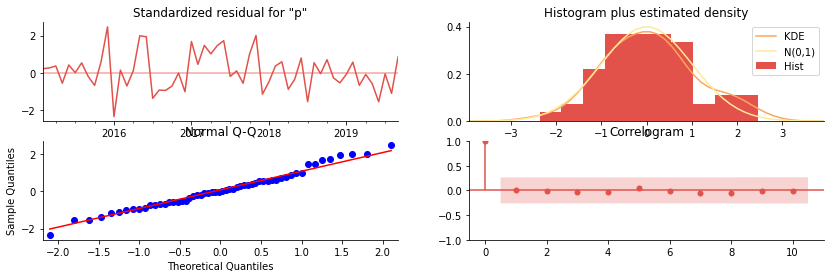

In [56]:
ax = model_fit.plot_diagnostics(figsize=(14, 4))
sns.despine()

<p> The Q-Q plot shows us a thick straight line that is roughly lying on y = x. Therefore, we can conclude that the residuals are approximately normally distributed. This in turn means that our model is a good fit for our data.<p>
<p> In the Correlogram, the residuals are not correlated, which further supports the conclusion that they are similar to white noise, which what we expect from a good model.

In [66]:
ARMA_preds = model_fit.predict(start=ARMA_test.index[0], end=test.index[-1], dynamic=True)

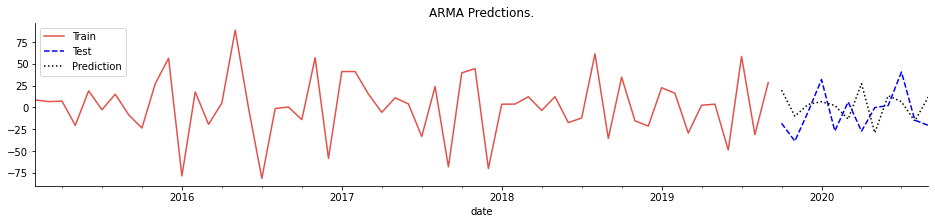

In [67]:
plt.figure(figsize=(16,3))
ARMA_train.plot()
ARMA_test.plot(color='b', linestyle='--')
ARMA_preds.plot(color='k', linestyle=':')
plt.title('ARMA Predctions.')
plt.legend(['Train', 'Test', 'Prediction'], loc='upper left')
sns.despine()

In [68]:
mape_ARMA = mape(test, ARMA_preds)
print(f'Our ARMA model deviates {str(mape_ARMA)}% from actual values.')

Our ARMA model deviates 96.0% from actual values.
